# Everything You Need to Know About Mathematics
## Chapter 1: What is Mathematics?

---

Working through Chapter 1. The closing question about the converse of the Pythagorean theorem stopped me cold at first — it looks simple but there's a real subtlety hiding inside it. Writing these notes to think it all the way through.

---

## The Question

> If we give you three positive numbers $a, b, c$ that satisfy $a^2 + b^2 = c^2$, is it necessarily true that there is a right triangle with side lengths $a$, $b$ and hypotenuse length $c$? If so, how could you go about constructing it? If not, why not?

### Why This Is Trickier Than It Looks

My first instinct was: *obviously yes, that's just Pythagoras*. But wait — the Pythagorean theorem says:

> If a triangle is a right triangle, then $a^2 + b^2 = c^2$.

This question is asking the **converse**:

> If $a^2 + b^2 = c^2$, then is the triangle necessarily a right triangle?

In logic, a statement and its converse are **not automatically the same thing**. You have to prove the converse separately. This is a really important lesson from the proof chapter — never assume the reverse direction is free.

So the real question is: **does $a^2 + b^2 = c^2$ force a right angle to exist, or could some weird triangle satisfy the equation without being right-angled?**

---

## Part 1: My First Instinct — Build the Triangle by Construction

This is the approach I thought of first, and I think it's the right one.

### The Construction Idea

Instead of asking *"does the triangle exist?"*, I'll just **build** it step by step:

1. Draw a line segment of length $a$ — call it $AB$
2. At the endpoint $B$, draw a line segment of length $b$ **perpendicular** to $AB$ — call this endpoint $C$
3. Connect $A$ to $C$ — this creates the third side

By **construction**, I already have a right angle at $B$. That's the key move: I'm not hoping for a right angle — I'm **forcing** one in by making $b$ perpendicular to $a$.

### What Is the Length of $AC$?

Now I apply the Pythagorean theorem to the triangle I just built (which is a right triangle by construction):

$$|AC|^2 = a^2 + b^2$$

But I was given that $a^2 + b^2 = c^2$. So:

$$|AC|^2 = c^2 \implies |AC| = c$$

(taking positive square root, since lengths are positive)

So the third side is **exactly** $c$.

### What Did I Just Prove?

I constructed a triangle with:
- Side $AB = a$ ✅
- Side $BC = b$ ✅
- Side $AC = c$ ✅
- Right angle at $B$ (built in by the perpendicular) ✅

So yes — a right triangle with those side lengths **exists**, and I can always build it this way.

### The Key Insight

The construction works because:
- I used the perpendicular to **guarantee** the right angle
- The equation $a^2 + b^2 = c^2$ then **forces** the hypotenuse to be exactly $c$

This is a very common move in geometry proofs: instead of arguing abstractly, just construct the object you want, and then show it has all the required properties.

---

## Part 2: Visualizing the Construction

Let me draw this out for a concrete example. Use $a = 3$, $b = 4$, $c = 5$ — a classic Pythagorean triple.

Check: $3^2 + 4^2 = 9 + 16 = 25 = 5^2$ ✅

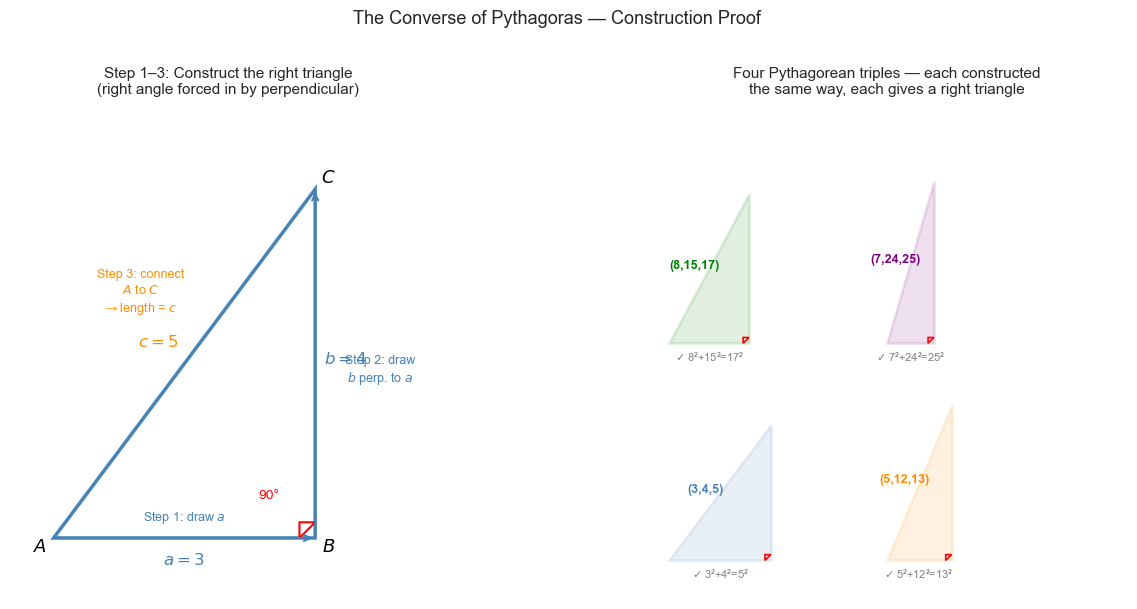

Verification of Pythagorean triples:
  (3, 4, 5): 3² + 4² = 9 + 16 = 25, c² = 25 → ✅
  (5, 12, 13): 5² + 12² = 25 + 144 = 169, c² = 169 → ✅
  (8, 15, 17): 8² + 15² = 64 + 225 = 289, c² = 289 → ✅
  (7, 24, 25): 7² + 24² = 49 + 576 = 625, c² = 625 → ✅


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, FancyArrowPatch

%matplotlib inline
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left plot: The construction steps ---
ax = axes[0]

# Triangle vertices: A at origin, B along x-axis, C straight up from B
A = np.array([0, 0])
B = np.array([3, 0])   # AB = a = 3 (horizontal)
C = np.array([3, 4])   # BC = b = 4 (perpendicular, vertical)

# Draw triangle
triangle = plt.Polygon([A, B, C], fill=False, edgecolor='steelblue', linewidth=2.5)
ax.add_patch(triangle)

# Draw right angle marker at B
sq_size = 0.18
right_angle = plt.Polygon(
    [B + np.array([-sq_size, 0]),
     B + np.array([-sq_size, sq_size]),
     B + np.array([0, sq_size])],
    fill=False, edgecolor='red', linewidth=1.5
)
ax.add_patch(right_angle)

# Label vertices
offset = 0.15
ax.text(A[0] - offset, A[1] - offset, '$A$', fontsize=13, ha='center', color='black')
ax.text(B[0] + offset, B[1] - offset, '$B$', fontsize=13, ha='center', color='black')
ax.text(C[0] + offset, C[1] + offset * 0.5, '$C$', fontsize=13, ha='center', color='black')

# Label sides
ax.text(1.5, -0.3, '$a = 3$', fontsize=12, ha='center', color='steelblue')
ax.text(3.35, 2.0, '$b = 4$', fontsize=12, ha='center', color='steelblue')
ax.text(1.2, 2.2, '$c = 5$', fontsize=12, ha='center', color='darkorange')

# Annotate right angle
ax.text(2.35, 0.45, '90°', fontsize=10, color='red')

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.7, 5.0)
ax.set_aspect('equal')
ax.set_title('Step 1–3: Construct the right triangle\n(right angle forced in by perpendicular)', fontsize=11)
ax.axis('off')

# Construction arrows and annotations
ax.annotate('', xy=(3, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
ax.text(1.5, 0.2, 'Step 1: draw $a$', fontsize=9, color='steelblue', ha='center')

ax.annotate('', xy=(3, 4), xytext=(3, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
ax.text(3.75, 1.8, 'Step 2: draw\n$b$ perp. to $a$', fontsize=9, color='steelblue', ha='center')

ax.text(1.0, 2.6, 'Step 3: connect\n$A$ to $C$\n→ length = $c$', fontsize=9, color='darkorange', ha='center')

# --- Right plot: Multiple Pythagorean triples ---
ax2 = axes[1]

triples = [(3, 4, 5), (5, 12, 13), (8, 15, 17), (7, 24, 25)]
colors_t = ['steelblue', 'darkorange', 'green', 'purple']

for idx, ((a, b, c), col) in enumerate(zip(triples, colors_t)):
    scale = 3.5 / max(a, b, c)
    offset_x = (idx % 2) * 4.5
    offset_y = (idx // 2) * 4.5

    A2 = np.array([offset_x, offset_y])
    B2 = np.array([offset_x + a * scale, offset_y])
    C2 = np.array([offset_x + a * scale, offset_y + b * scale])

    tri = plt.Polygon([A2, B2, C2], fill=True, facecolor=col, alpha=0.12,
                      edgecolor=col, linewidth=2)
    ax2.add_patch(tri)

    # Right angle marker
    sq = 0.12
    rm = plt.Polygon(
        [B2 + np.array([-sq, 0]),
         B2 + np.array([-sq, sq]),
         B2 + np.array([0, sq])],
        fill=False, edgecolor='red', linewidth=1.2
    )
    ax2.add_patch(rm)

    mid_hyp = (A2 + C2) / 2
    ax2.text(mid_hyp[0] - 0.3, mid_hyp[1], f'({a},{b},{c})', fontsize=9,
             ha='center', color=col, fontweight='bold')

    check = f'$\\checkmark$ {a}²+{b}²={c}²'
    ax2.text(offset_x + a * scale / 2, offset_y - 0.35, check,
             fontsize=8, ha='center', color='gray')

ax2.set_xlim(-0.5, 9.5)
ax2.set_ylim(-0.8, 9.5)
ax2.set_aspect('equal')
ax2.set_title('Four Pythagorean triples — each constructed\nthe same way, each gives a right triangle', fontsize=11)
ax2.axis('off')

plt.suptitle('The Converse of Pythagoras — Construction Proof', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Verification of Pythagorean triples:")
for a, b, c in triples:
    print(f"  ({a}, {b}, {c}): {a}² + {b}² = {a**2} + {b**2} = {a**2+b**2}, c² = {c**2} → {'✅' if a**2+b**2==c**2 else '❌'}")

---

## Part 3: Why the Construction Proof is Actually Complete

I want to make sure I understand why this construction is a **full proof** and not just a sketch.

### The Argument Written Cleanly

**Given:** three positive numbers $a, b, c$ with $a^2 + b^2 = c^2$.

**Goal:** show there exists a right triangle with legs $a$, $b$ and hypotenuse $c$.

**Proof:**

Construct a triangle as follows:
- Draw segment $AB$ with $|AB| = a$
- At point $B$, erect a segment $BC$ with $|BC| = b$, perpendicular to $AB$
- Connect $A$ to $C$

By the (forward) Pythagorean theorem applied to this right triangle $ABC$ (which has a right angle at $B$ **by construction**):

$$|AC|^2 = |AB|^2 + |BC|^2 = a^2 + b^2 = c^2$$

Since $|AC| > 0$, we get $|AC| = c$.

Therefore, triangle $ABC$ is a right triangle with legs $a$ and $b$, and hypotenuse $c$. $\blacksquare$

### Why This Uses the Forward Pythagorean Theorem (Not the Converse)

This is a subtle but important point:

- I did **not** need the converse of Pythagoras to prove this
- I built a right triangle first, then used the forward Pythagorean theorem to compute the hypotenuse
- The equation $a^2 + b^2 = c^2$ tells me the hypotenuse I compute is exactly $c$

So the proof is self-contained and clean. No circular reasoning.

---

## Part 4: The Contradiction Approach — What Happens If the Angle Isn't 90°?

I also thought about a second approach: assume the triangle exists but the angle is **not** 90°, and derive a contradiction.

### Setup

Suppose we have a triangle with sides $a$, $b$, $c$ satisfying $a^2 + b^2 = c^2$, but the angle $\theta$ between sides $a$ and $b$ is **not** a right angle. Either $\theta < 90°$ or $\theta > 90°$.

### The Law of Cosines

The **Law of Cosines** generalizes Pythagoras to any triangle:

$$c^2 = a^2 + b^2 - 2ab\cos\theta$$

This holds for any triangle, regardless of angles.

### Plugging In

We know $c^2 = a^2 + b^2$, so:

$$a^2 + b^2 = a^2 + b^2 - 2ab\cos\theta$$

Subtract $a^2 + b^2$ from both sides:

$$0 = -2ab\cos\theta$$

Since $a > 0$ and $b > 0$ (given as positive numbers), $2ab \neq 0$. So:

$$\cos\theta = 0 \implies \theta = 90°$$

### What Just Happened?

We didn't even need to assume a contradiction. The Law of Cosines directly **forces** $\theta = 90°$. Any triangle with sides satisfying $a^2 + b^2 = c^2$ must have a right angle between $a$ and $b$. There's no wiggle room.

### The Two Approaches Compared

| Approach | What it does | Tools used |
|----------|-------------|------------|
| Construction | Builds a right triangle directly, shows the hypotenuse must be $c$ | Perpendicular lines, forward Pythagoras |
| Law of Cosines | Takes any triangle with $a^2+b^2=c^2$, forces the angle to be 90° | Algebra, $\cos 90° = 0$ |

Both work. The construction is more elementary (no need for the Law of Cosines). The algebraic one is more direct if you have that tool available.

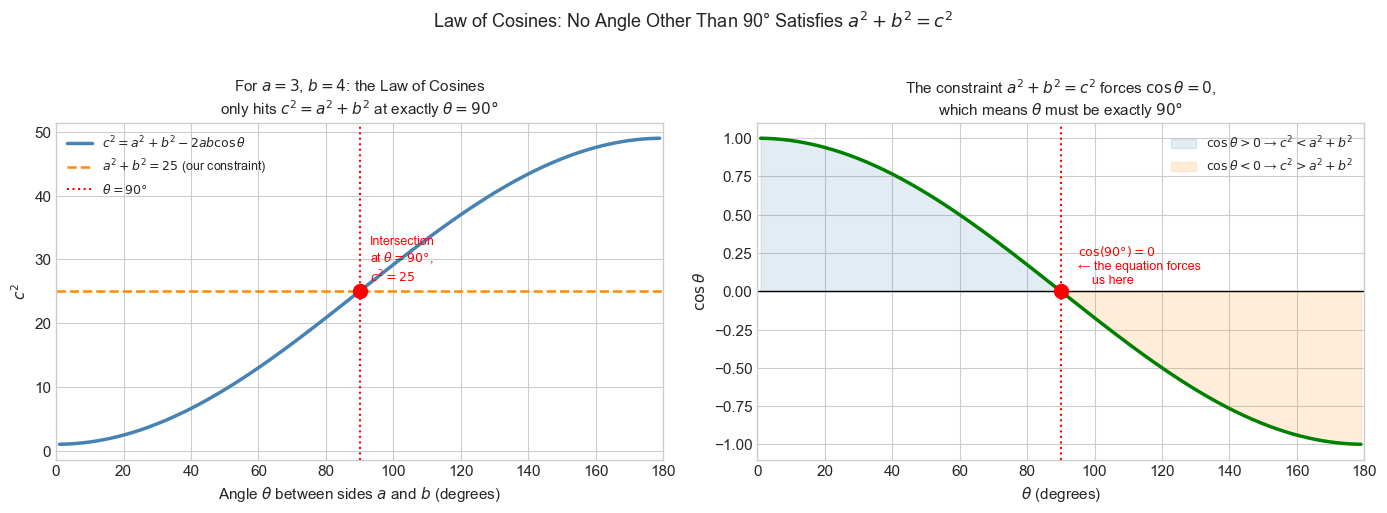

Law of Cosines check:
  a=3, b=4, a²+b² = 25
  c² = a²+b² - 2ab·cos(θ)
  For c² = a²+b²: we need -2ab·cos(θ) = 0
  Since 2ab = 24 ≠ 0, we need cos(θ) = 0 → θ = 90°

  Verification at θ=90°: c² = 9 + 16 - 24·cos(90°) = 25 - 0 = 25 ✅


In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)

# Show visually: for fixed a=3, b=4, what happens to c² as theta varies?
# Law of cosines: c² = a² + b² - 2ab*cos(theta)
# When theta=90 degrees, c² = a² + b²

a, b = 3, 4
c_squared_target = a**2 + b**2  # = 25

theta_deg = np.linspace(1, 179, 500)
theta_rad = np.radians(theta_deg)
c_squared = a**2 + b**2 - 2 * a * b * np.cos(theta_rad)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: c² vs theta
ax = axes[0]
ax.plot(theta_deg, c_squared, color='steelblue', linewidth=2.5, label='$c^2 = a^2 + b^2 - 2ab\\cos\\theta$')
ax.axhline(y=c_squared_target, color='darkorange', linestyle='--', linewidth=1.8,
           label=f'$a^2 + b^2 = {c_squared_target}$ (our constraint)')
ax.axvline(x=90, color='red', linestyle=':', linewidth=1.5, label='$\\theta = 90°$')

# Mark the intersection
ax.scatter([90], [c_squared_target], color='red', s=100, zorder=5)
ax.text(93, c_squared_target + 1.5, f'Intersection\nat $\\theta=90°$,\n$c^2={c_squared_target}$',
        fontsize=9, color='red')

ax.set_xlabel('Angle $\\theta$ between sides $a$ and $b$ (degrees)')
ax.set_ylabel('$c^2$')
ax.set_title(f'For $a={a}$, $b={b}$: the Law of Cosines\nonly hits $c^2=a^2+b^2$ at exactly $\\theta=90°$', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 180)

# Right: Show cos(theta) = 0 argument visually
ax2 = axes[1]
ax2.plot(theta_deg, np.cos(theta_rad), color='green', linewidth=2.5)
ax2.axhline(y=0, color='black', linewidth=1.0)
ax2.axvline(x=90, color='red', linestyle=':', linewidth=1.5)
ax2.scatter([90], [0], color='red', s=100, zorder=5)
ax2.text(95, 0.05, '$\\cos(90°) = 0$\n← the equation forces\n    us here', fontsize=9, color='red')

# Shade the two cases
ax2.fill_between(theta_deg[theta_deg < 90], np.cos(theta_rad[theta_deg < 90]), 0,
                 alpha=0.15, color='steelblue', label='$\\cos\\theta > 0$ → $c^2 < a^2+b^2$')
ax2.fill_between(theta_deg[theta_deg > 90], np.cos(theta_rad[theta_deg > 90]), 0,
                 alpha=0.15, color='darkorange', label='$\\cos\\theta < 0$ → $c^2 > a^2+b^2$')

ax2.set_xlabel('$\\theta$ (degrees)')
ax2.set_ylabel('$\\cos\\theta$')
ax2.set_title('The constraint $a^2+b^2=c^2$ forces $\\cos\\theta=0$,\nwhich means $\\theta$ must be exactly $90°$', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 180)

plt.suptitle('Law of Cosines: No Angle Other Than 90° Satisfies $a^2+b^2=c^2$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Verify algebraically
print("Law of Cosines check:")
print(f"  a={a}, b={b}, a²+b² = {a**2+b**2}")
print(f"  c² = a²+b² - 2ab·cos(θ)")
print(f"  For c² = a²+b²: we need -2ab·cos(θ) = 0")
print(f"  Since 2ab = {2*a*b} ≠ 0, we need cos(θ) = 0 → θ = 90°")
print(f"\n  Verification at θ=90°: c² = {a**2} + {b**2} - {2*a*b}·cos(90°) = {a**2+b**2} - 0 = {a**2+b**2} ✅")

---

## Part 5: The Euclid Connection

I also thought about using Euclid's own proof framework. This is essentially Euclid's **Proposition 48 from Book I** — often called the *converse of the Pythagorean theorem*.

### Euclid's Approach (Book I, Prop. 48)

The idea is exactly the construction approach, but stated more carefully:

1. Take triangle $ABC$ with sides $a, b, c$ and $a^2 + b^2 = c^2$
2. Construct a **new** right triangle $ABD$ with legs $a$ and $b$ (right angle at $B$)
3. By the forward Pythagorean theorem (Book I, Prop. 47), the hypotenuse of $ABD$ has length $\sqrt{a^2 + b^2} = c$
4. So triangles $ABC$ and $ABD$ have all three sides equal
5. By **SSS congruence** (Book I, Prop. 8), they are congruent
6. Since $ABD$ has a right angle at $B$, so does $ABC$

### The SSS Congruence Step

This is the Euclidean version of what I described intuitively. Two triangles with the same three side lengths are congruent — they're the same triangle, just possibly reflected or rotated. So they must have the same angles too.

This is actually the **most rigorous** version of the proof, because it doesn't assume the Law of Cosines (which itself requires proof). It only uses tools Euclid had already established by Book I, Proposition 47.

### The Chain of Logic

$$a^2 + b^2 = c^2 \xrightarrow{\text{construct}} \text{right triangle with legs } a, b \xrightarrow{\text{Pythagoras}} \text{hypotenuse} = c \xrightarrow{\text{SSS}} \text{original triangle is right-angled}$$

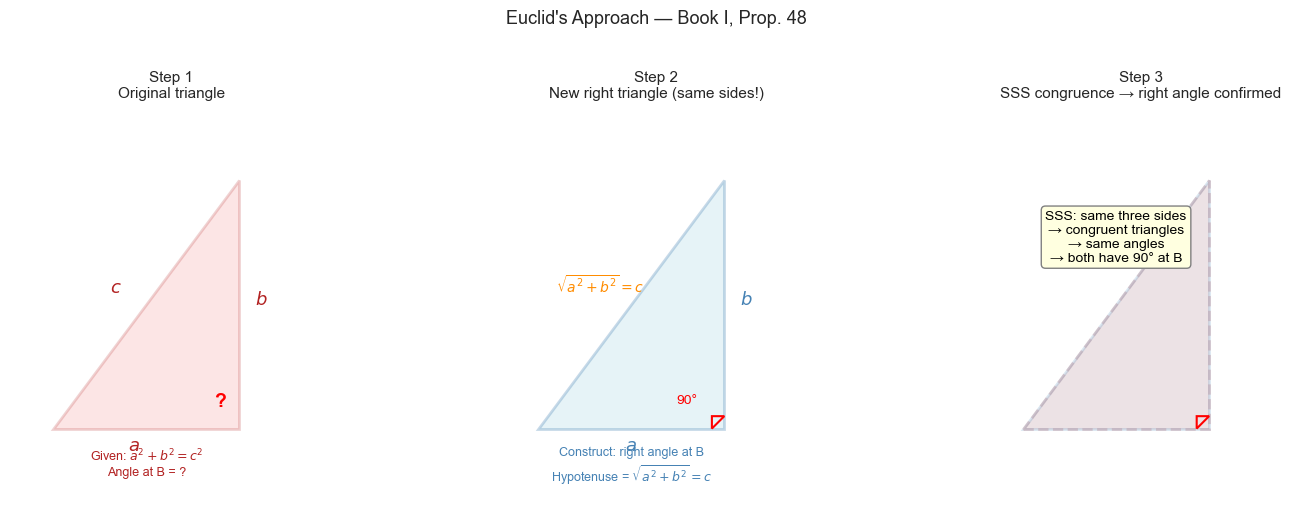

Euclid's proof chain:
  1. Given triangle with a²+b²=c²
  2. Construct a NEW right triangle with the same legs a, b
  3. By Pythagoras (forward), its hypotenuse = √(a²+b²) = c
  4. Both triangles now have sides: a, b, c
  5. SSS congruence → they are the same triangle
  6. The constructed one has 90° at B → so does the original ✅


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

%matplotlib inline
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: Step 1 — Original triangle (unknown angle) ---
ax = axes[0]
# Slightly tilted triangle so it doesn't look like a right triangle
A1 = np.array([0.5, 0])
B1 = np.array([3.5, 0])
C1 = np.array([3.5, 4.0])

tri1 = plt.Polygon([A1, B1, C1], fill=True, facecolor='lightcoral', alpha=0.2,
                   edgecolor='firebrick', linewidth=2)
ax.add_patch(tri1)
ax.text(1.8, -0.35, '$a$', fontsize=13, ha='center', color='firebrick')
ax.text(3.85, 2.0, '$b$', fontsize=13, ha='center', color='firebrick')
ax.text(1.5, 2.2, '$c$', fontsize=13, ha='center', color='firebrick')
ax.text(3.2, 0.35, '?', fontsize=14, ha='center', color='red', fontweight='bold')
ax.text(2.0, -0.75, 'Given: $a^2+b^2=c^2$\nAngle at B = ?', fontsize=9, ha='center', color='firebrick')
ax.set_xlim(-0.2, 5)
ax.set_ylim(-1.2, 5.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Step 1\nOriginal triangle', fontsize=11)

# --- Panel 2: Step 2 — Construct new right triangle ---
ax2 = axes[1]
A2 = np.array([0.5, 0])
B2 = np.array([3.5, 0])
D2 = np.array([3.5, 4.0])

tri2 = plt.Polygon([A2, B2, D2], fill=True, facecolor='lightblue', alpha=0.3,
                   edgecolor='steelblue', linewidth=2)
ax2.add_patch(tri2)

sq = 0.2
right_sq = plt.Polygon(
    [B2 + np.array([-sq, 0]),
     B2 + np.array([-sq, sq]),
     B2 + np.array([0, sq])],
    fill=False, edgecolor='red', linewidth=1.5
)
ax2.add_patch(right_sq)

ax2.text(2.0, -0.35, '$a$', fontsize=13, ha='center', color='steelblue')
ax2.text(3.85, 2.0, '$b$', fontsize=13, ha='center', color='steelblue')
ax2.text(1.5, 2.2, '$\\sqrt{a^2+b^2}=c$', fontsize=10, ha='center', color='darkorange')
ax2.text(2.9, 0.4, '90°', fontsize=10, ha='center', color='red')
ax2.text(2.0, -0.85, 'Construct: right angle at B\nHypotenuse = $\\sqrt{a^2+b^2} = c$', fontsize=9, ha='center', color='steelblue')
ax2.set_xlim(-0.2, 5)
ax2.set_ylim(-1.2, 5.2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Step 2\nNew right triangle (same sides!)', fontsize=11)

# --- Panel 3: SSS congruence conclusion ---
ax3 = axes[2]
# Show both triangles overlaid
tri_orig = plt.Polygon([A1, B1, C1], fill=True, facecolor='lightcoral', alpha=0.2,
                       edgecolor='firebrick', linewidth=2, linestyle='--')
tri_new = plt.Polygon([A2, B2, D2], fill=True, facecolor='lightblue', alpha=0.2,
                      edgecolor='steelblue', linewidth=2)
ax3.add_patch(tri_orig)
ax3.add_patch(tri_new)

sq2 = 0.2
right_sq2 = plt.Polygon(
    [B2 + np.array([-sq2, 0]),
     B2 + np.array([-sq2, sq2]),
     B2 + np.array([0, sq2])],
    fill=False, edgecolor='red', linewidth=1.5
)
ax3.add_patch(right_sq2)

ax3.text(2.0, 2.7, 'SSS: same three sides\n→ congruent triangles\n→ same angles\n→ both have 90° at B',
         fontsize=10, ha='center', color='black',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax3.set_xlim(-0.2, 5)
ax3.set_ylim(-1.2, 5.2)
ax3.set_aspect('equal')
ax3.axis('off')
ax3.set_title('Step 3\nSSS congruence → right angle confirmed', fontsize=11)

plt.suptitle("Euclid's Approach — Book I, Prop. 48", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Euclid's proof chain:")
print("  1. Given triangle with a²+b²=c²")
print("  2. Construct a NEW right triangle with the same legs a, b")
print("  3. By Pythagoras (forward), its hypotenuse = √(a²+b²) = c")
print("  4. Both triangles now have sides: a, b, c")
print("  5. SSS congruence → they are the same triangle")
print("  6. The constructed one has 90° at B → so does the original ✅")

---

## Summary — What I Learned From This Question

### The Answer

**Yes** — if $a^2 + b^2 = c^2$, then there always exists a right triangle with legs $a$, $b$ and hypotenuse $c$.

### Three Ways to See It

| Method | Core idea | Level |
|--------|-----------|-------|
| **Construction** | Build a right triangle with legs $a$, $b$ using a perpendicular; Pythagoras forces the hypotenuse to be $c$ | Elementary |
| **Euclid (SSS)** | Construct a right triangle → it has the same three sides → SSS congruence → same angles | Classical geometry |
| **Law of Cosines** | $c^2 = a^2+b^2-2ab\cos\theta$ + $c^2=a^2+b^2$ → $\cos\theta=0$ → $\theta=90°$ | Algebra |

### The Deeper Lesson — Forward vs. Converse

The thing that tripped me up at first was not distinguishing:

- **Forward:** right triangle $\Rightarrow$ $a^2+b^2=c^2$ *(this is the standard Pythagorean theorem)*
- **Converse:** $a^2+b^2=c^2$ $\Rightarrow$ right triangle *(this is what the question asks)*

In this case, both directions happen to be true — but they require **separate proofs**. The forward direction does not automatically give you the converse for free. This is a general principle I want to keep in mind: always ask whether the converse of a theorem you're using is actually established.

### What I Want to Revisit

- Euclid's Book I, Prop. 47 (forward Pythagoras) — I want to read the original proof
- SSS congruence (Book I, Prop. 8) — to make sure I understand why equal sides force equal angles
- The Law of Cosines proof itself — since I used it as a tool here without proving it

---

## Section 5: There Are Infinitely Many Primes

This came up as part of Chapter 1 and it wrecked me at first. The proof itself is short, but every single line hides a subtlety. I'm going to unpack each piece until it makes sense.

### The Claim

> There are infinitely many prime numbers.

### The Strategy: Proof by Contradiction

We assume the opposite — that there are only *finitely* many primes — and show that assumption leads to a logical impossibility.

**Assume:** the complete list of all primes is $p_1, p_2, \ldots, p_k$ (some finite list).

**Build:** a new number

$$N = (p_1 \cdot p_2 \cdots p_k) + 1$$

This is just: multiply all the primes together, then add 1.

### Step 1 — $N$ Must Have a Prime Divisor

This is the step that confused me most. Here's why it's always true:

Every integer greater than 1 either:
- **is** prime (so it's its own prime divisor), or
- **is composite** — meaning it factors into smaller pieces, and those pieces eventually break down into primes

There is **no third option**. There is no number $> 1$ that avoids primes entirely. This comes from the Fundamental Theorem of Arithmetic.

So whatever $N$ is, some prime must divide it.

### Step 2 — None of the Primes in Our List Divide $N$

Now check: can any $p_i$ from our list divide $N$?

$$N = (\underbrace{p_1 \cdot p_2 \cdots p_k}_{\text{divisible by } p_i}) + 1$$

Dividing $N$ by $p_i$:

$$N \equiv 1 \pmod{p_i}$$

The remainder is always 1 — never 0. So **none of $p_1, \ldots, p_k$ divides $N$**.

### Step 3 — The Contradiction

We now have two facts that cannot both be true:

| Fact | Source |
|------|--------|
| $N$ must be divisible by some prime | Fundamental Theorem of Arithmetic |
| None of $p_1, \ldots, p_k$ divides $N$ | The $+1$ construction |

If those are supposed to be *all* the primes, then $N$ has no prime divisor — which is impossible.

**Therefore, the assumption that there are only finitely many primes must be wrong.**

### My Own Intuition for This

I think of it like this: the "+1" trick is designed to guarantee that $N$ leaves a remainder of 1 when divided by any prime on the list. It's like building a number that is deliberately "one step ahead" of every prime you know. Whatever prime eventually divides $N$, it can't be on your list — so your list was always incomplete.

### Important: The Proof Does NOT Say $N$ is Prime

This tripped me up. $N$ itself might not be prime. For example:

$$2 \times 3 \times 5 \times 7 \times 11 \times 13 + 1 = 30031 = 59 \times 509$$

$30031$ is **not** prime — but $59$ and $509$ are both primes not on the original list. The proof says a *new* prime must exist somewhere, not that $N$ itself is that prime.

In [10]:
from math import gcd as _gcd
from sympy import isprime, factorint

# Demonstrate the N = (p1*p2*...*pk) + 1 construction with concrete numbers

def primes_up_to_n(n):
    """Return list of primes up to n using a simple sieve."""
    sieve = [True] * (n + 1)
    sieve[0] = sieve[1] = False
    for i in range(2, int(n**0.5) + 1):
        if sieve[i]:
            for j in range(i*i, n+1, i):
                sieve[j] = False
    return [i for i in range(n+1) if sieve[i]]

print("The 'infinitely many primes' construction — worked examples\n")
print(f"{'List used':^40} | {'N':>10} | {'N prime?':^10} | {'Factors of N':^25} | {'New prime(s)?'}")
print("─" * 105)

# Try growing lists of known primes
for k in range(1, 8):
    known_primes = primes_up_to_n(20)[:k]
    product = 1
    for p in known_primes:
        product *= p
    N = product + 1

    factors = factorint(N)
    is_prime_N = isprime(N)
    new_primes = [p for p in factors if p not in known_primes]

    prime_str = "yes ✅" if is_prime_N else "no"
    new_str = str(new_primes) if new_primes else "N itself is new ✅"

    print(f"  {str(known_primes):^40} | {N:>10} | {prime_str:^10} | {str(dict(factors)):^25} | {new_str}")

print()
print("Observations:")
print("  • N is sometimes prime itself (e.g., 2×3+1=7), sometimes not (2×3×5×7×11×13+1=30031=59×509)")
print("  • In EVERY case, the prime factors of N are NOT in the original list")
print("  • This is the contradiction: those factors are new primes that 'shouldn't exist'")
print()

# Show the remainder argument clearly
print("Why no p_i divides N — the remainder argument:\n")
known = [2, 3, 5, 7]
product = 2 * 3 * 5 * 7
N = product + 1
print(f"  List: {known}")
print(f"  Product: {product}")
print(f"  N = {product} + 1 = {N}")
print()
for p in known:
    remainder = N % p
    print(f"  {N} ÷ {p} = {N // p} remainder {remainder}  →  N ≡ {remainder} (mod {p})  → {p} does NOT divide N {'✅' if remainder != 0 else '❌'}")

The 'infinitely many primes' construction — worked examples

               List used                 |          N |  N prime?  |       Factors of N        | New prime(s)?
─────────────────────────────────────────────────────────────────────────────────────────────────────────
                    [2]                    |          3 |   yes ✅    |          {3: 1}           | [3]
                   [2, 3]                  |          7 |   yes ✅    |          {7: 1}           | [7]
                 [2, 3, 5]                 |         31 |   yes ✅    |          {31: 1}          | [31]
                [2, 3, 5, 7]               |        211 |   yes ✅    |         {211: 1}          | [211]
              [2, 3, 5, 7, 11]             |       2311 |   yes ✅    |         {2311: 1}         | [2311]
            [2, 3, 5, 7, 11, 13]           |      30031 |     no     |      {59: 1, 509: 1}      | [59, 509]
          [2, 3, 5, 7, 11, 13, 17]         |     510511 |     no     |  {19: 1, 97: 1, 277: 

---

## Section 6: Write Right — What Makes a Valid Proof?

This section of the book is about the *writing* side of mathematics, not just the calculation side. A proof needs to satisfy three standards:

| Standard | What it means |
|----------|--------------|
| **Precise** | Every statement is unambiguously true — no illegal steps, no hidden assumptions |
| **Logical** | Each step genuinely follows from the ones before it |
| **Clear** | Written in proper language so a reader can follow the reasoning |

The book uses two deliberately broken "proofs" to show what happens when these standards are violated. I found both of them confusing at first — here's how I worked through them.

---

## Bad Proof #1: "Proof" that $1 = 2$

### What they do

Start with $x = y$, do some algebra, and conclude $2 = 1$. You're supposed to spot the error.

The steps:

$$x = y$$
$$x^2 = xy \quad \text{(multiply both sides by } x\text{)}$$
$$x^2 - y^2 = xy - y^2 \quad \text{(subtract } y^2\text{)}$$
$$(x+y)(x-y) = y(x-y) \quad \text{(factor both sides)}$$
$$x + y = y \quad \text{(cancel } (x-y)\text{)}$$
$$2y = y \quad \text{(since } x = y\text{)}$$
$$2 = 1 \quad \text{(divide by } y\text{)}$$

### Where it breaks

The problem is in the step where they "cancel $(x - y)$ from both sides." That's division by $(x - y)$.

But from the very first line: $x = y$, which means $x - y = 0$.

**They divided by zero.**

### Why division by zero is illegal

I had to think about this one carefully. The book asks: *why* is it not allowed?

Think about what division means in terms of multiplication. To say $\frac{a}{b} = c$ means $b \cdot c = a$. So asking "what is $\frac{a}{0}$?" means asking: what number $c$ satisfies $0 \cdot c = a$?

But $0 \cdot c = 0$ for *every* $c$. So:
- If $a \neq 0$: no solution exists at all
- If $a = 0$: every number is a solution — it's completely undefined

Either way, $\frac{a}{0}$ is not a valid number. The moment you allow division by zero, you can "prove" anything — which is exactly what this bad proof does.

### Standard violated: **Precision**

The step looks legitimate at a glance (cancelling a common factor is usually fine), but hides an illegal operation. That's a precision failure — a step that is not actually true.

---

## Bad Proof #2: "Proof" that $0 = 36$

### What they do

Start with $x^2 + y^2 = 25$, rearrange, then plug in $x = -3$, $y = 4$ and conclude $0 = 36$.

### The key step that breaks it

They write:

$$x^2 + y^2 = 25 \implies x = \sqrt{25 - y^2}$$

The problem: this only gives the **positive** square root.

In reality:

$$x^2 = 25 - y^2 \implies x = \sqrt{25 - y^2} \quad \text{OR} \quad x = -\sqrt{25 - y^2}$$

When they chose $x = -3$ and $y = 4$:

$$\sqrt{25 - 16} = \sqrt{9} = 3$$

But $x = -3$, not $+3$. They should have used the **negative** root. By silently using the positive root, they built an equation that is inconsistent with the values they later plug in — so of course it produces nonsense.

### The rule to remember

Going **forward** (squaring both sides of an equation) is always safe:

$$a = b \implies a^2 = b^2 \quad \checkmark$$

Going **backward** (taking a square root) requires caution:

$$a^2 = b^2 \implies a = b \quad \text{OR} \quad a = -b$$

You can't just pick one. Squaring *destroys sign information* — both $3$ and $-3$ square to $9$, so knowing the square is $9$ doesn't tell you which one you had.

### A simple way to see the sign loss

$$3^2 = 9 \quad \text{and} \quad (-3)^2 = 9$$

After squaring, both give $9$. You've lost the sign. So going backwards, you have to keep both options.

### Standard violated: **Logic**

The step from $x^2 + y^2 = 25$ to $x = \sqrt{25 - y^2}$ does not *logically follow* — it's only half of the correct conclusion. That's a logic failure.

---

## Summary — The Two Bad Proofs

| | Bad Proof #1 | Bad Proof #2 |
|---|---|---|
| **False conclusion** | $1 = 2$ | $0 = 36$ |
| **The error** | Divided by $x - y = 0$ | Took only the positive square root |
| **Why it's sneaky** | The algebra looks normal until you track $x - y = 0$ | The choice of $x = -3$ seems fine until you check the root |
| **Standard violated** | Precision | Logic |
| **The lesson** | Always check: are you dividing by something that could be 0? | Always check: when you take a square root, do you need $\pm$? |

These two examples are the book's way of showing that a *proof* is not just "steps that look like math." Every step has to be genuinely valid.

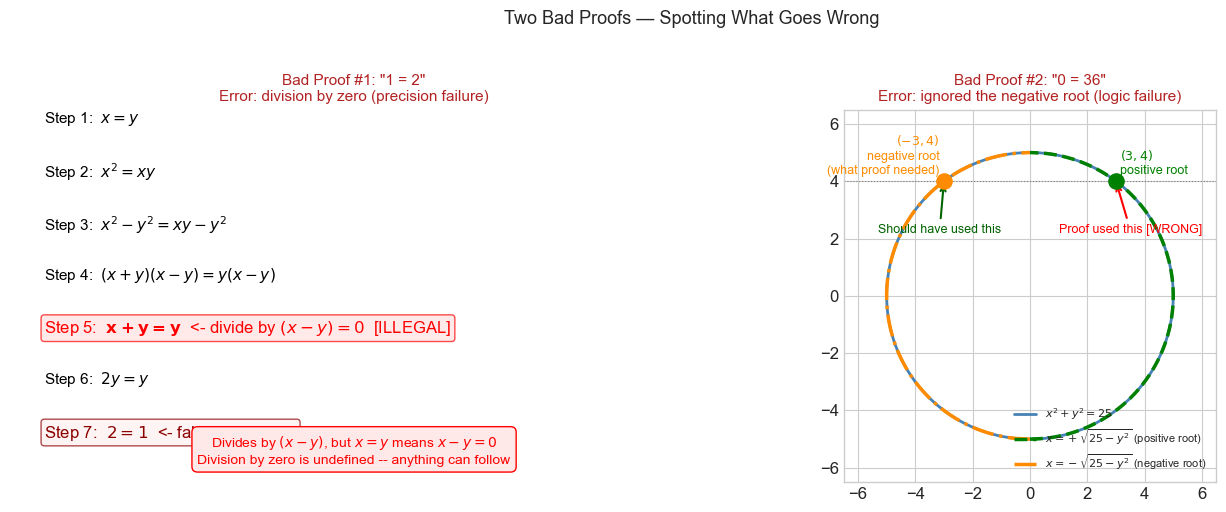

Sign loss when squaring — numerical demonstration:

  Both 3 and -3 square to 9:
    3^2   = 9
    (-3)^2 = 9

  So if you know x^2 = 9, you cannot just say x = 3.
  You must say x = 3 OR x = -3.

  Bad Proof #2 plugged in x = -3 but used the formula x = +sqrt(25 - y^2).
  At y=4:  +sqrt(25-16) = +sqrt(9) = +3,  but x = -3.
  The proof used a formula inconsistent with its own choice of x. [INVALID]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bad Proof #1 — division by zero ---
ax = axes[0]

steps = [
    r'$x = y$',
    r'$x^2 = xy$',
    r'$x^2 - y^2 = xy - y^2$',
    r'$(x+y)(x-y) = y(x-y)$',
    r'$\mathbf{x + y = y}$  <- divide by $(x-y) = 0$  [ILLEGAL]',
    r'$2y = y$',
    r'$2 = 1$  <- false conclusion',
]
colors = ['black'] * 4 + ['red', 'black', 'darkred']
sizes  = [11] * 4 + [12, 11, 12]

for i, (step, col, sz) in enumerate(zip(steps, colors, sizes)):
    ax.text(0.05, 1 - i * 0.14, f'Step {i+1}:  {step}',
            transform=ax.transAxes, fontsize=sz, color=col, va='top',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='#ffe0e0' if col == 'red' else ('#fff0f0' if col == 'darkred' else 'white'),
                      edgecolor=col, alpha=0.7) if col != 'black' else None)

ax.text(0.5, 0.05, 'Divides by $(x-y)$, but $x=y$ means $x-y=0$\nDivision by zero is undefined -- anything can follow',
        transform=ax.transAxes, fontsize=10, ha='center', color='red',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe8e8', edgecolor='red'))

ax.axis('off')
ax.set_title('Bad Proof #1: "1 = 2"\nError: division by zero (precision failure)', fontsize=11, color='firebrick')

# --- Right: Bad Proof #2 — sign loss when squaring ---
ax2 = axes[1]

y_range = np.linspace(-5, 5, 400)

# Circle x^2 + y^2 = 25
theta = np.linspace(0, 2 * np.pi, 400)
ax2.plot(5 * np.cos(theta), 5 * np.sin(theta), 'steelblue', linewidth=2,
         label='$x^2 + y^2 = 25$')

# The two branches of x = ±√(25 - y²)
x_pos = np.sqrt(np.maximum(0, 25 - y_range**2))
x_neg = -x_pos

ax2.plot(x_pos, y_range, 'green', linewidth=2.5, linestyle='--',
         label=r'$x = +\sqrt{25-y^2}$ (positive root)')
ax2.plot(x_neg, y_range, 'darkorange', linewidth=2.5, linestyle='-.',
         label=r'$x = -\sqrt{25-y^2}$ (negative root)')

# Mark the two solutions at y=4
ax2.scatter([3], [4], color='green', s=120, zorder=5)
ax2.scatter([-3], [4], color='darkorange', s=120, zorder=5)
ax2.text(3.15, 4.25, '$(3, 4)$\npositive root', fontsize=9, color='green')
ax2.text(-3.15, 4.25, '$(-3, 4)$\nnegative root\n(what proof needed)', fontsize=9,
         color='darkorange', ha='right')

ax2.annotate('Proof used this [WRONG]', xy=(3, 4), xytext=(1, 2.2),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=9, color='red')
ax2.annotate('Should have used this', xy=(-3, 4), xytext=(-1, 2.2),
             arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
             fontsize=9, color='darkgreen', ha='right')

ax2.axhline(y=4, color='gray', linewidth=0.8, linestyle=':')
ax2.set_xlim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
ax2.set_aspect('equal')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_title('Bad Proof #2: "0 = 36"\nError: ignored the negative root (logic failure)', fontsize=11, color='firebrick')

plt.suptitle('Two Bad Proofs — Spotting What Goes Wrong', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Demonstrate the sign issue numerically
print("Sign loss when squaring — numerical demonstration:\n")
print("  Both 3 and -3 square to 9:")
print(f"    3^2   = {3**2}")
print(f"    (-3)^2 = {(-3)**2}")
print()
print("  So if you know x^2 = 9, you cannot just say x = 3.")
print("  You must say x = 3 OR x = -3.\n")
print("  Bad Proof #2 plugged in x = -3 but used the formula x = +sqrt(25 - y^2).")
print(f"  At y=4:  +sqrt(25-16) = +sqrt(9) = +3,  but x = -3.")
print("  The proof used a formula inconsistent with its own choice of x. [INVALID]")

# Everything You Need to Know About Mathematics
## Chapter 1: What Is Mathematics? — The Converse of the Pythagorean Theorem

---

I'm working through Chapter 1 and this question stopped me cold:

> *If three positive numbers $a, b, c$ satisfy $a^2 + b^2 = c^2$, is it necessarily true that there is a right triangle with side lengths $a$, $b$ and hypotenuse $c$?*

My first instinct was — obviously yes, that's just the Pythagorean theorem. But then I realised the book is asking something subtler. The Pythagorean theorem says:

> **If** a triangle is a right triangle **then** $a^2 + b^2 = c^2$.

The question is asking about the **converse**:

> **If** $a^2 + b^2 = c^2$ **then** is the triangle necessarily a right triangle?

These are two completely different claims. The fact that one is true doesn't automatically make the other true. I had to think about this carefully.

---

## My Initial Confusion

I kept going in circles. I thought: well, any three lengths $a, b, c$ that satisfy $a^2 + b^2 = c^2$ *can* form a triangle — but does that triangle *have* to have a right angle? I wasn't sure whether:

1. The equation $a^2 + b^2 = c^2$ is enough to *force* a right angle, or
2. Some other shape (non-right triangle) could also satisfy it.

The key realisation I needed: **a triangle's shape is completely determined by its three side lengths.** There's no wiggle room. Given $a$, $b$, $c$, there is essentially one triangle (up to flipping and rotating). So the question becomes: is there even a valid triangle, and if so, what shape must it be?

---

## The Answer: Yes, It Is a Right Triangle — And Here's Why

The answer is **yes** — if $a^2 + b^2 = c^2$, then a right triangle with those side lengths necessarily exists and can be constructed.

### The Construction (This is What the Book is Hinting At)

Here's how I'd construct it:

1. Draw a line segment of length $a$.
2. At one endpoint, erect a **perpendicular** line.
3. Along that perpendicular, mark off a length $b$.
4. Connect the two free endpoints.

By the Pythagorean theorem (the *forward* direction), the hypotenuse of this right angle construction is $\sqrt{a^2 + b^2}$. But we assumed $a^2 + b^2 = c^2$, so the hypotenuse has length $\sqrt{c^2} = c$. ✅

So we've *built* a triangle with sides $a$, $b$, $c$ that has a right angle by construction.

### But Wait — Is That the Only Triangle with Those Side Lengths?

Yes — by the **SSS congruence theorem** (Side-Side-Side). Two triangles with the same three side lengths must be congruent — same shape, same angles. Since our constructed triangle has a right angle, **any** triangle with the same side lengths must also have a right angle. The equation $a^2 + b^2 = c^2$ forces it.

### The Role in the Book

This question teaches me something important: **the converse of a true statement is not automatically true.** You have to check it separately. In this case, the converse of the Pythagorean theorem *is* true — but proving it requires the SSS argument, not just citing the theorem itself.

---

## What I'll Explore in This Notebook

| Section | What I'm checking |
|---------|-------------------|
| **1** | Verify $a^2 + b^2 = c^2$ numerically for known triples |
| **2** | Plot and visualise a right triangle from a triple |
| **3** | Simulate the compass-and-straightedge construction in Python |
| **4** | Generate many Pythagorean triples and inspect them |

---

## Section 1: Verify the Relationship Numerically

Before building any intuition, I want to just *see* that $a^2 + b^2 = c^2$ holds for known examples — and confirm that when it does, a right triangle really is there.

In [7]:
from sympy import sqrt, Rational, simplify, symbols, Eq, latex
import sympy as sp

# Check several triples — integer and non-integer — that satisfy a^2 + b^2 = c^2
# I want to see both exact integers and scaled/non-integer examples

triples = [
    (3, 4, 5),
    (5, 12, 13),
    (8, 15, 17),
    (7, 24, 25),
    (Rational(3, 2), 2, Rational(5, 2)),     # scaled 3-4-5 by 1/2
    (1, 1, sqrt(2)),                           # isoceles right triangle
    (Rational(6, 5), Rational(8, 5), 2),       # scaled 3-4-5 by 2/5
]

print(f"{'a':>10} {'b':>10} {'c':>12} | {'a²+b²':>12} {'c²':>12} | holds?")
print("─" * 70)

for a, b, c in triples:
    lhs = simplify(a**2 + b**2)
    rhs = simplify(c**2)
    holds = simplify(lhs - rhs) == 0
    marker = "✅" if holds else "❌"
    print(f"{str(a):>10} {str(b):>10} {str(c):>12} | {str(lhs):>12} {str(rhs):>12} | {marker}")

print()
print("Every triple where a² + b² = c² holds can form a right triangle.")
print("The equation is the *complete* fingerprint of the right angle.")

         a          b            c |        a²+b²           c² | holds?
──────────────────────────────────────────────────────────────────────
         3          4            5 |           25           25 | ✅
         5         12           13 |          169          169 | ✅
         8         15           17 |          289          289 | ✅
         7         24           25 |          625          625 | ✅
       3/2          2          5/2 |         25/4         25/4 | ✅
         1          1      sqrt(2) |            2            2 | ✅
       6/5        8/5            2 |            4            4 | ✅

Every triple where a² + b² = c² holds can form a right triangle.
The equation is the *complete* fingerprint of the right angle.


---

## Section 2: Visualise a Right Triangle from a Pythagorean Triple

I want to actually *see* the triangle. The right angle should sit at the corner between sides $a$ and $b$, with $c$ as the hypotenuse connecting the far ends.

### What I Expect to See

- Two legs $a$ and $b$ meeting at a right angle (the small square marker in the corner confirms this)
- The hypotenuse $c$ closing the triangle
- The angle opposite the hypotenuse should be exactly $90°$ — I'll verify it using the dot product

### Why the Dot Product Confirms the Right Angle

If I place the right angle at the origin, one leg goes along the positive $x$-axis (length $a$) and the other goes straight up the $y$-axis (length $b$). The vectors are:

$$\vec{u} = (a, 0) \qquad \vec{v} = (0, b)$$

Their dot product is $\vec{u} \cdot \vec{v} = a \cdot 0 + 0 \cdot b = 0$. **Zero dot product means perpendicular — that's the right angle.**

This is what "constructing by placing legs perpendicular" actually means geometrically.

Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


Dot product verification (right angle check):

  Triple (3, 4, 5):
  Dot product of the two legs: [3 0] · [0 4] = 0
  → Perpendicular ✅ (right angle confirmed)

  Triple (5, 12, 13):
  Dot product of the two legs: [5 0] · [ 0 12] = 0
  → Perpendicular ✅ (right angle confirmed)

  Triple (8, 15, 17):
  Dot product of the two legs: [8 0] · [ 0 15] = 0
  → Perpendicular ✅ (right angle confirmed)



Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


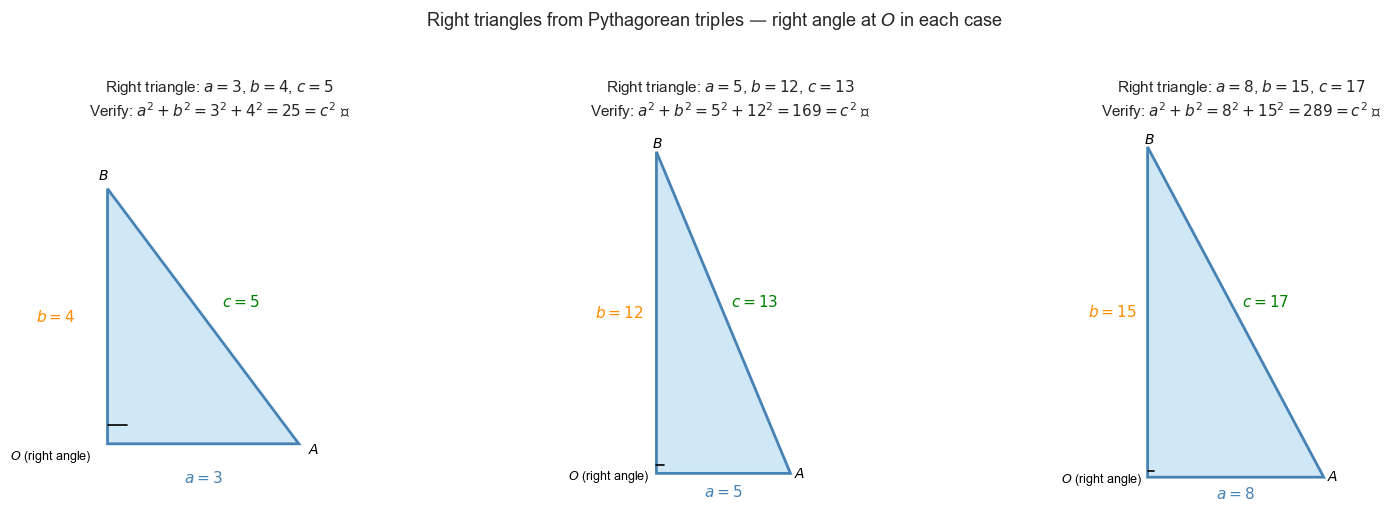

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc

%matplotlib inline
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(_style)
plt.rcParams['font.size'] = 12

def plot_right_triangle(a, b, label="", ax=None):
    """
    Plot a right triangle with legs a, b and hypotenuse sqrt(a^2 + b^2).
    Right angle is at the origin.
    """
    c = np.sqrt(a**2 + b**2)

    # Vertices: right angle at origin, legs along axes
    O = np.array([0, 0])   # right angle
    A = np.array([a, 0])   # end of horizontal leg
    B = np.array([0, b])   # end of vertical leg

    triangle = plt.Polygon([O, A, B], fill=True, facecolor='#d0e8f5',
                            edgecolor='steelblue', linewidth=2, zorder=2)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.add_patch(triangle)

    # Right angle marker
    sq = mpatches.FancyArrowPatch(
        (0.3, 0), (0.3, 0.3),
        arrowstyle='-', color='black', linewidth=1.2
    )
    ax.add_patch(sq)
    ax.plot([0, 0.3], [0.3, 0.3], color='black', linewidth=1.2)

    # Side labels
    ax.text(a / 2, -0.4, f'$a = {a}$', ha='center', va='top',
            fontsize=11, color='steelblue', fontweight='bold')
    ax.text(-0.5, b / 2, f'$b = {b}$', ha='right', va='center',
            fontsize=11, color='darkorange', fontweight='bold')

    mid_hyp = ((A + B) / 2)
    ax.text(mid_hyp[0] + 0.3, mid_hyp[1] + 0.1,
            f'$c = {c:.4g}$', ha='left', va='bottom',
            fontsize=11, color='green', fontweight='bold')

    # Vertex labels
    ax.text(-0.25, -0.25, '$O$ (right angle)', ha='right', fontsize=9, color='black')
    ax.text(a + 0.15, -0.15, '$A$', fontsize=10, color='black')
    ax.text(-0.15, b + 0.15, '$B$', fontsize=10, color='black')

    ax.set_xlim(-1, a + 1.5)
    ax.set_ylim(-0.8, b + 1)
    ax.set_aspect('equal')
    ax.set_title(f'Right triangle: $a={a}$, $b={b}$, $c={c:.4g}$\n'
                 f'Verify: $a^2 + b^2 = {a}^2 + {b}^2 = {a**2 + b**2:.4g} = c^2$ ✅',
                 fontsize=11)
    ax.axis('off')

    # Verify right angle via dot product
    u = A - O
    v = B - O
    dot = np.dot(u, v)
    print(f"  Dot product of the two legs: {u} · {v} = {dot}")
    print(f"  → {'Perpendicular ✅ (right angle confirmed)' if abs(dot) < 1e-10 else 'NOT perpendicular ❌'}")

    return ax

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
triples_plot = [(3, 4), (5, 12), (8, 15)]
labels = ['(3, 4, 5)', '(5, 12, 13)', '(8, 15, 17)']

print("Dot product verification (right angle check):\n")
for ax, (a, b), lbl in zip(axes, triples_plot, labels):
    print(f"  Triple {lbl}:")
    plot_right_triangle(a, b, label=lbl, ax=ax)
    print()

plt.suptitle('Right triangles from Pythagorean triples — right angle at $O$ in each case',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Section 3: The Compass-and-Straightedge Construction

This is how the book hints I should think about it. Given $a$, $b$, $c$ with $a^2 + b^2 = c^2$, here's how to *construct* the right triangle:

### The Construction Steps

| Step | Action | Tool |
|------|--------|------|
| 1 | Draw a horizontal segment of length $a$ | Straightedge |
| 2 | At the left endpoint, erect a **perpendicular** line (straight up) | Straightedge |
| 3 | Mark off length $b$ along that perpendicular | Compass |
| 4 | Connect the two free endpoints | Straightedge |

The resulting hypotenuse has length $\sqrt{a^2 + b^2}$. Since we assumed $a^2 + b^2 = c^2$, this equals $c$. ✅

### Why This Proves the Converse

I *built* a right triangle by putting the $90°$ angle in explicitly (step 2). The only reason the third side comes out to exactly $c$ (rather than some other length) is the assumption $a^2 + b^2 = c^2$. And by SSS congruence, every triangle with these three side lengths is congruent to this one — so every such triangle must have a right angle.

Below I simulate this construction: starting from the hypotenuse endpoint, I draw two circles (radius $a$ and radius $b$) and find their intersection — that's the right-angle vertex.

Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


Construction verification:

  Triangle (3, 4, 5):
    P3 = (1.8000, 2.4000)
    |P1–P3| = 3.000000  (should be 3)
    |P2–P3| = 4.000000  (should be 4)
    |P1–P2| = 5.000000  (should be 5)
    Angle at P3 = 90.00000000°  ← right angle ✅

  Triangle (5, 12, 13):
    P3 = (1.9231, 4.6154)
    |P1–P3| = 5.000000  (should be 5)
    |P2–P3| = 12.000000  (should be 12)
    |P1–P2| = 13.000000  (should be 13)
    Angle at P3 = 90.00000000°  ← right angle ✅

  Triangle (8, 15, 17):
    P3 = (3.7647, 7.0588)
    |P1–P3| = 8.000000  (should be 8)
    |P2–P3| = 15.000000  (should be 15)
    |P1–P2| = 17.000000  (should be 17)
    Angle at P3 = 90.00000000°  ← right angle ✅



Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


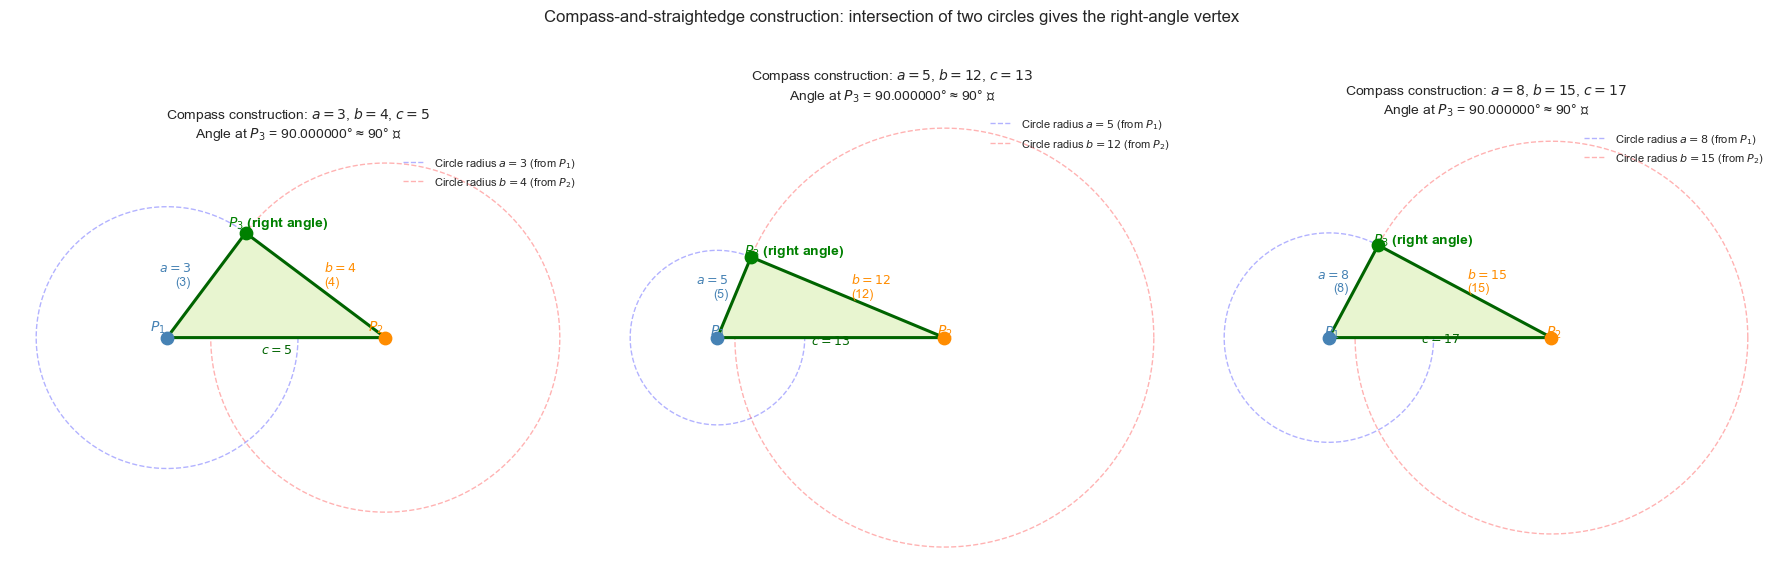

In [9]:
def compass_construction(a, b, ax=None):
    """
    Simulate the compass-and-straightedge construction of a right triangle.

    Strategy:
      - Place the hypotenuse endpoints at P1 = (0, 0) and P2 = (c, 0).
      - Draw circle of radius a centred at P1.
      - Draw circle of radius b centred at P2.
      - Their intersection is the right-angle vertex P3.
      - We then confirm the angle at P3 is 90 degrees.

    Why this works: if a^2 + b^2 = c^2 then the two circles intersect at
    exactly the right-angle vertex of the triangle.
    """
    c = np.sqrt(a**2 + b**2)

    # Hypotenuse endpoints
    P1 = np.array([0.0, 0.0])
    P2 = np.array([c, 0.0])

    # Analytically find intersection of:
    #   circle 1: x^2 + y^2 = a^2  (centred at P1)
    #   circle 2: (x-c)^2 + y^2 = b^2 (centred at P2)
    # Subtract: x^2 - (x-c)^2 = a^2 - b^2
    #           2cx - c^2 = a^2 - b^2
    #           x = (a^2 - b^2 + c^2) / (2c)
    x3 = (a**2 - b**2 + c**2) / (2 * c)
    y3 = np.sqrt(max(0, a**2 - x3**2))
    P3 = np.array([x3, y3])

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    # Draw construction circles (dashed, light)
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(P1[0] + a * np.cos(theta), P1[1] + a * np.sin(theta),
            'b--', alpha=0.3, linewidth=1, label=f'Circle radius $a={a}$ (from $P_1$)')
    ax.plot(P2[0] + b * np.cos(theta), P2[1] + b * np.sin(theta),
            'r--', alpha=0.3, linewidth=1, label=f'Circle radius $b={b}$ (from $P_2$)')

    # Draw the triangle
    tri = plt.Polygon([P1, P2, P3], fill=True, facecolor='#e8f5d0',
                      edgecolor='darkgreen', linewidth=2.2, zorder=3)
    ax.add_patch(tri)

    # Highlight vertices
    for P, name, col in zip([P1, P2, P3], ['$P_1$', '$P_2$', '$P_3$ (right angle)'],
                             ['steelblue', 'darkorange', 'green']):
        ax.scatter(*P, color=col, s=80, zorder=5)
        offset = [-0.4, 0.15]
        ax.text(P[0] + offset[0], P[1] + offset[1], name,
                fontsize=10, color=col, fontweight='bold')

    # Side labels
    mid_P1P3 = (P1 + P3) / 2
    mid_P2P3 = (P2 + P3) / 2
    mid_P1P2 = (P1 + P2) / 2
    dist_P1P3 = np.linalg.norm(P3 - P1)
    dist_P2P3 = np.linalg.norm(P3 - P2)
    dist_P1P2 = np.linalg.norm(P2 - P1)

    ax.text(mid_P1P3[0] - 0.35, mid_P1P3[1],
            f'$a = {a}$\n({dist_P1P3:.4g})', ha='right', fontsize=9, color='steelblue')
    ax.text(mid_P2P3[0] + 0.2, mid_P2P3[1],
            f'$b = {b}$\n({dist_P2P3:.4g})', ha='left', fontsize=9, color='darkorange')
    ax.text(mid_P1P2[0], mid_P1P2[1] - 0.35,
            f'$c = {c:.4g}$', ha='center', fontsize=9, color='darkgreen')

    # Angle at P3 verification
    v1 = P1 - P3
    v2 = P2 - P3
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

    ax.set_title(f'Compass construction: $a={a}$, $b={b}$, $c={c:.4g}$\n'
                 f'Angle at $P_3$ = {angle_deg:.6f}° '
                 f'{"≈ 90° ✅" if abs(angle_deg - 90) < 1e-6 else "≠ 90° ❌"}',
                 fontsize=10)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    ax.axis('off')

    # Print angle proof
    print(f"  Triangle ({a}, {b}, {c:.4g}):")
    print(f"    P3 = ({x3:.4f}, {y3:.4f})")
    print(f"    |P1–P3| = {dist_P1P3:.6f}  (should be {a})")
    print(f"    |P2–P3| = {dist_P2P3:.6f}  (should be {b})")
    print(f"    |P1–P2| = {dist_P1P2:.6f}  (should be {c:.4g})")
    print(f"    Angle at P3 = {angle_deg:.8f}°  ← right angle ✅" if abs(angle_deg - 90) < 1e-6
          else f"    Angle at P3 = {angle_deg:.8f}° ← NOT right ❌")
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
triples_cc = [(3, 4), (5, 12), (8, 15)]

print("Construction verification:\n")
for ax, (a, b) in zip(axes, triples_cc):
    compass_construction(a, b, ax=ax)

plt.suptitle('Compass-and-straightedge construction: intersection of two circles gives the right-angle vertex',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

## Section 4: Exploring Pythagorean Triples

Now I want to *generate* many triples $(a, b, c)$ satisfying $a^2 + b^2 = c^2$ and see what they look like.

### Two Types of Triples

| Type | What it means | Example |
|------|--------------|---------|
| **Primitive** | $\gcd(a, b, c) = 1$ — no common factor | $(3, 4, 5)$ |
| **Non-primitive** | Scaled-up version of a primitive | $(6, 8, 10)$ — just $2 \times (3, 4, 5)$ |

Every non-primitive triple is just a scaled primitive one. Scaling by $k$ means:

$$(ka)^2 + (kb)^2 = k^2(a^2 + b^2) = k^2 c^2 = (kc)^2$$

So the equation is preserved under scaling — which makes sense geometrically (similar triangles).

### The Euclid Formula (Nice to Know)

Every primitive Pythagorean triple can be generated by:

$$a = m^2 - n^2, \quad b = 2mn, \quad c = m^2 + n^2$$

where $m > n > 0$, $\gcd(m, n) = 1$, and $m - n$ is odd. I'll use brute force below but verify this formula too.

In [ ]:
from math import gcd, isqrt

def find_pythagorean_triples(limit=100, primitive_only=False):
    """Brute-force search for triples (a, b, c) with a <= b < c <= limit."""
    triples = []
    for a in range(1, limit + 1):
        for b in range(a, limit + 1):
            c_sq = a**2 + b**2
            c = isqrt(c_sq)
            if c * c == c_sq and c <= limit:
                is_primitive = gcd(gcd(a, b), c) == 1
                triples.append((a, b, c, is_primitive))
    return triples

triples = find_pythagorean_triples(limit=100)
primitive = [(a, b, c) for a, b, c, p in triples if p]
non_primitive = [(a, b, c) for a, b, c, p in triples if not p]

print(f"Pythagorean triples with a ≤ b < c ≤ 100:")
print(f"  Total found:     {len(triples)}")
print(f"  Primitive:       {len(primitive)}")
print(f"  Non-primitive:   {len(non_primitive)}\n")

print(f"{'a':>6} {'b':>6} {'c':>6} | {'a²+b²':>8} = {'c²':>8} | primitive?")
print("─" * 52)
for a, b, c, prim in triples[:25]:
    print(f"{a:>6} {b:>6} {c:>6} | {a**2 + b**2:>8} = {c**2:>8} | {'✅ yes' if prim else '  no (scaled)'}")

print(f"\n... ({len(triples) - 25} more triples not shown)\n")

# Show the scaling relationship for non-primitives
print("Examples of scaling relationships:")
print("  (6, 8, 10)  = 2 × (3, 4, 5)")
print("  (9, 12, 15) = 3 × (3, 4, 5)")
print("  (5, 12, 13) is primitive — can't be simplified")
print("  (10, 24, 26) = 2 × (5, 12, 13)")

In [ ]:
# Plot all triples as triangles, scaled to the same height,
# so I can see how diverse the shapes are

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes_flat = axes.flatten()

# Use the first 20 primitive triples
show_triples = primitive[:20]

for ax, (a, b, c) in zip(axes_flat, show_triples):
    O = np.array([0.0, 0.0])
    A = np.array([float(a), 0.0])
    B = np.array([0.0, float(b)])

    tri = plt.Polygon([O, A, B], fill=True, facecolor='#d4ecd4',
                      edgecolor='green', linewidth=1.8, zorder=2)
    ax.add_patch(tri)

    # Right angle marker
    s = min(a, b) * 0.12
    ax.plot([s, s], [0, s], color='black', linewidth=1)
    ax.plot([0, s], [s, s], color='black', linewidth=1)

    ax.set_xlim(-0.5, a + 1)
    ax.set_ylim(-0.5, b + 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'$({a}, {b}, {c})$', fontsize=9)

# Hide unused axes
for ax in axes_flat[len(show_triples):]:
    ax.axis('off')

plt.suptitle('First 20 primitive Pythagorean triples — each satisfies $a^2 + b^2 = c^2$\n'
             'Every triangle has a right angle at the bottom-left corner',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Verify every single triple we found
print("Verification: a² + b² = c² for all triples found?\n")
all_ok = True
for a, b, c, _ in triples:
    if a**2 + b**2 != c**2:
        print(f"  ❌ FAILED: ({a}, {b}, {c})")
        all_ok = False
if all_ok:
    print(f"  ✅ All {len(triples)} triples verified: a² + b² = c² holds for every one.")